In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plot_benchmark
from pathlib import Path
import os

%load_ext autoreload
%autoreload
%matplotlib inline

time_results = Path("../results/2025-10-25_18-51_Benchmark_Result_RTX2080_without_shr.csv")
code_complexity_results = Path("../results/code-complexity_without_shr.csv")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
df_results = pd.read_csv(time_results)
df_results

,Name,Framework,Precision,Problem Size,Iterations,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Time Unit,Version,Framework[Version]
0,MatrixMultiplication,Alpaka,float,32,8176.0,7.831260e+04,7.812443e+04,2.394853e+04,NaN,NaN,NaN,ns,NaN,Alpaka
1,MatrixMultiplication,Alpaka,float,64,6900.0,1.129272e+05,1.126394e+05,3.995484e+04,NaN,NaN,NaN,ns,NaN,Alpaka
2,MatrixMultiplication,Alpaka,float,128,4426.0,1.576464e+05,1.573337e+05,7.470166e+04,NaN,NaN,NaN,ns,NaN,Alpaka
3,MatrixMultiplication,Alpaka,float,256,1168.0,6.227995e+05,6.217590e+05,4.624265e+05,NaN,NaN,NaN,ns,NaN,Alpaka
4,MatrixMultiplication,Alpaka,float,512,176.0,3.889060e+06,3.883924e+06,3.329796e+06,NaN,NaN,NaN,ns,NaN,Alpaka
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,PolyhedralGravity,Slang-CUDA,float,255932,368.0,2.006543e+06,2.005559e+06,NaN,NaN,NaN,NaN,ns,NaN,Slang-CUDA
225,PolyhedralGravity,Slang-Vulkan,float,14744,10000.0,4.852684e+05,8.806955e+03,NaN,NaN,NaN,NaN,ns,NaN,Slang-Vulkan
226,PolyhedralGravity,Slang-Vulkan,float,255932,1000.0,9.450042e+06,2.772756e+04,NaN,NaN,NaN,NaN,ns,NaN,Slang-Vulkan
227,PolyhedralGravity,CPP,float,14744,383.0,1.814547e+06,1.814384e+06,NaN,NaN,NaN,NaN,ns,NaN,CPP


Compute and append Halstead metrics (n, N, V, D, E) to df_complexity and df_merged using:
- n = n1 + n2
- N = N1 + N2
- V = N * log2(n)
- D = (n1 / 2) * (N2 / n2)
- E = D * V

In [56]:
df_complexity = pd.read_csv(code_complexity_results)
df_complexity["n"] = df_complexity["n1"] + df_complexity["n2"]
df_complexity["N"] = df_complexity["N1"] + df_complexity["N2"]
df_complexity["V"] = df_complexity["N"] * np.log2(df_complexity["n"].replace(0, np.nan))
df_complexity["D"] = (df_complexity["n1"] / 2) * (df_complexity["N2"] / df_complexity["n2"].replace(0, np.nan))
df_complexity["E"] = df_complexity["D"] * df_complexity["V"]
df_complexity

,Name,Framework,SLOC,n1,n2,N1,N2,n,N,V,D,E
0,VecAdd,CPP,30,37,42,183,89,79,272,1714.628364,39.202381,6.721751e+04
1,VecAdd,Alpaka,83,44,96,487,295,140,782,5575.099319,67.604167,3.768999e+05
2,VecAdd,Boost,49,51,57,322,187,108,509,3438.237739,83.657895,2.876357e+05
3,VecAdd,AdaptiveCpp,47,52,64,338,154,116,492,3374.126650,62.562500,2.110938e+05
4,VecAdd,Cuda,76,61,48,399,172,109,571,3864.633249,109.291667,4.223722e+05
5,VecAdd,Cublas,66,48,47,368,159,95,527,3462.313906,81.191489,2.811104e+05
6,VecAdd,OpenACC,41,52,52,246,123,104,369,2472.462256,61.500000,1.520564e+05
7,VecAdd,OpenCL,143,82,96,894,369,178,1263,9441.851323,157.593750,1.487977e+06
8,VecAdd,OpenMP,37,45,53,219,121,98,340,2249.001347,51.367925,1.155265e+05
9,VecAdd,Vulkan,206,92,198,1394,769,290,2163,17693.143362,178.656566,3.160996e+06


In [57]:
# Merge df_results and df_complexity on ['Name', 'Framework']
df_merged = pd.merge(df_results, df_complexity, on=["Name", "Framework"], how="inner")
df_merged = df_merged.drop(columns=["Version", "Framework[Version]", "Precision", "Iterations", "Time Unit"])
df_merged


,Name,Framework,Problem Size,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,SLOC,n1,n2,N1,N2,n,N,V,D,E
0,MatrixMultiplication,Alpaka,32,7.831260e+04,7.812443e+04,2.394853e+04,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
1,MatrixMultiplication,Alpaka,64,1.129272e+05,1.126394e+05,3.995484e+04,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
2,MatrixMultiplication,Alpaka,128,1.576464e+05,1.573337e+05,7.470166e+04,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
3,MatrixMultiplication,Alpaka,256,6.227995e+05,6.217590e+05,4.624265e+05,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
4,MatrixMultiplication,Alpaka,512,3.889060e+06,3.883924e+06,3.329796e+06,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,PolyhedralGravity,Kokkos,255932,1.822498e+06,1.822280e+06,NaN,NaN,NaN,NaN,551,89,250,3555,2010,339,5565,46774.612242,357.780000,1.673502e+07
225,PolyhedralGravity,Slang-Vulkan,14744,4.852684e+05,8.806955e+03,NaN,NaN,NaN,NaN,922,183,509,5077,3201,692,8278,78099.852468,575.425344,4.494063e+07
226,PolyhedralGravity,Slang-Vulkan,255932,9.450042e+06,2.772756e+04,NaN,NaN,NaN,NaN,922,183,509,5077,3201,692,8278,78099.852468,575.425344,4.494063e+07
227,PolyhedralGravity,CPP,14744,1.814547e+06,1.814384e+06,NaN,NaN,NaN,NaN,541,79,239,3262,1955,318,5217,43368.310378,323.106695,1.401259e+07


In [58]:
# Only get the rows where: Name == MatrixMultiplication && Problem Size == 8192
df_matMul8192 = df_merged.loc[(df_merged["Name"] == "MatrixMultiplication") & (df_merged["Problem Size"] == 8192)]
df_matMul8192.drop(columns=["Name", "Problem Size", "Position Update Time", "Velocity Update Time", "Force Update Time"], inplace=True)
# Remove the row with "cublas" == Name
df_matMul8192 = df_matMul8192.loc[df_matMul8192["Framework"] != "Cublas"]
df_matMul8192


/var/folders/d7/j4pv5c3d1nj5jmjlz_bpj2lh0000gn/T/ipykernel_34726/2687433048.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matMul8192.drop(columns=["Name", "Problem Size", "Position Update Time", "Velocity Update Time", "Force Update Time"], inplace=True)


,Framework,Wall Clock Time,CPU Time,Kernel Time,SLOC,n1,n2,N1,N2,n,N,V,D,E
8,Alpaka,6.127116e+10,6.124959e+10,6.113522e+10,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
17,OpenMP,6.263257e+09,2.155427e+08,6.118367e+09,52,47,71,333,192,118,525,3613.387601,63.549296,2.296282e+05
26,Vulkan,2.566473e+09,1.407050e+09,1.039213e+09,266,93,225,1749,978,318,2727,22669.231819,202.120000,4.581905e+06
35,AdaptiveCpp,1.281553e+10,1.277156e+10,1.257315e+10,67,61,85,474,241,146,715,5140.724560,86.476471,4.445517e+05
44,AdaptiveCpp-Shr,1.719032e+09,1.669362e+09,1.472255e+09,94,65,102,618,326,167,944,6970.216852,103.872549,7.240142e+05
53,CPP,4.392037e+10,4.391257e+10,4.377448e+10,48,45,59,292,160,104,452,3028.598753,61.016949,1.847959e+05
62,OpenCL,1.277653e+09,1.277451e+09,9.867201e+08,195,89,112,1157,501,201,1658,12685.443704,199.058036,2.525140e+06
71,Boost,1.115860e+09,1.115781e+09,9.766006e+08,106,57,97,618,356,154,974,7077.850091,104.597938,7.403285e+05
80,Kokkos,1.206508e+09,1.206387e+09,9.873899e+08,64,50,74,448,254,124,702,4881.845810,85.810811,4.189151e+05
98,Cuda,1.253993e+09,1.253933e+09,1.090497e+09,82,69,67,581,257,136,838,5939.293861,132.335821,7.859813e+05


In [59]:
# Compute normalized performance (higher is better, 100 = best/fastest)
def _normalize_inverse(series):
    min_val = series.min()
    return (min_val / series) * 100.0


df_matMul8192["Application Efficiency [%]"] = _normalize_inverse(df_matMul8192["Kernel Time"])
df_matMul8192


,Framework,Wall Clock Time,CPU Time,Kernel Time,SLOC,n1,n2,N1,N2,n,N,V,D,E,Application Efficiency [%]
8,Alpaka,6.127116e+10,6.124959e+10,6.113522e+10,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05,1.208455
17,OpenMP,6.263257e+09,2.155427e+08,6.118367e+09,52,47,71,333,192,118,525,3613.387601,63.549296,2.296282e+05,12.074982
26,Vulkan,2.566473e+09,1.407050e+09,1.039213e+09,266,93,225,1749,978,318,2727,22669.231819,202.120000,4.581905e+06,71.091428
35,AdaptiveCpp,1.281553e+10,1.277156e+10,1.257315e+10,67,61,85,474,241,146,715,5140.724560,86.476471,4.445517e+05,5.875949
44,AdaptiveCpp-Shr,1.719032e+09,1.669362e+09,1.472255e+09,94,65,102,618,326,167,944,6970.216852,103.872549,7.240142e+05,50.180965
53,CPP,4.392037e+10,4.391257e+10,4.377448e+10,48,45,59,292,160,104,452,3028.598753,61.016949,1.847959e+05,1.687722
62,OpenCL,1.277653e+09,1.277451e+09,9.867201e+08,195,89,112,1157,501,201,1658,12685.443704,199.058036,2.525140e+06,74.873481
71,Boost,1.115860e+09,1.115781e+09,9.766006e+08,106,57,97,618,356,154,974,7077.850091,104.597938,7.403285e+05,75.649317
80,Kokkos,1.206508e+09,1.206387e+09,9.873899e+08,64,50,74,448,254,124,702,4881.845810,85.810811,4.189151e+05,74.822692
98,Cuda,1.253993e+09,1.253933e+09,1.090497e+09,82,69,67,581,257,136,838,5939.293861,132.335821,7.859813e+05,67.748136


In [60]:
# Normalize Halstead Effort (E) so that the maximum is 100% and others are scaled accordingly
def _normalize_max(series):
    max_val = series.max()
    return (series / max_val) * 100.0 if max_val and np.isfinite(max_val) else series


df_matMul8192["E_normalized [%]"] = _normalize_max(df_matMul8192["E"])
df_matMul8192


,Framework,Wall Clock Time,CPU Time,Kernel Time,SLOC,n1,n2,N1,N2,n,N,V,D,E,Application Efficiency [%],E_normalized [%]
8,Alpaka,6.127116e+10,6.124959e+10,6.113522e+10,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05,1.208455,13.993581
17,OpenMP,6.263257e+09,2.155427e+08,6.118367e+09,52,47,71,333,192,118,525,3613.387601,63.549296,2.296282e+05,12.074982,5.011632
26,Vulkan,2.566473e+09,1.407050e+09,1.039213e+09,266,93,225,1749,978,318,2727,22669.231819,202.120000,4.581905e+06,71.091428,100.000000
35,AdaptiveCpp,1.281553e+10,1.277156e+10,1.257315e+10,67,61,85,474,241,146,715,5140.724560,86.476471,4.445517e+05,5.875949,9.702333
44,AdaptiveCpp-Shr,1.719032e+09,1.669362e+09,1.472255e+09,94,65,102,618,326,167,944,6970.216852,103.872549,7.240142e+05,50.180965,15.801597
53,CPP,4.392037e+10,4.391257e+10,4.377448e+10,48,45,59,292,160,104,452,3028.598753,61.016949,1.847959e+05,1.687722,4.033166
62,OpenCL,1.277653e+09,1.277451e+09,9.867201e+08,195,89,112,1157,501,201,1658,12685.443704,199.058036,2.525140e+06,74.873481,55.111126
71,Boost,1.115860e+09,1.115781e+09,9.766006e+08,106,57,97,618,356,154,974,7077.850091,104.597938,7.403285e+05,75.649317,16.157657
80,Kokkos,1.206508e+09,1.206387e+09,9.873899e+08,64,50,74,448,254,124,702,4881.845810,85.810811,4.189151e+05,74.822692,9.142816
98,Cuda,1.253993e+09,1.253933e+09,1.090497e+09,82,69,67,581,257,136,838,5939.293861,132.335821,7.859813e+05,67.748136,17.154029


In [61]:
def filter_and_normalize(df: pd.DataFrame,
                         name: str,
                         problem_size: int,
                         runtime: str = "Kernel Time",
                         exclude: str | list[str] = "Cublas") -> pd.DataFrame:
    """
    Filter by Name and Problem Size, exclude frameworks, and compute:
    - Application Efficiency [%]: normalized inverse of chosen runtime column (lower is better -> higher score)
    - E_normalized [%]: Halstead Effort normalized to max=100

    Parameters
    ----------
    df : pd.DataFrame
        Merged dataframe that contains runtime columns and Halstead metrics.
    name : str
        Value to match in 'Name'.
    problem_size : int
        Value to match in 'Problem Size'.
    runtime : str, default "Kernel Time"
        Column to use for application efficiency (e.g., "Kernel Time", "CPU Time", "Wall Clock Time").
    exclude : str | list[str], default "Cublas"
        Framework name(s) to exclude entirely.

    Returns
    -------
    pd.DataFrame
        Filtered dataframe with added columns:
        - "Application Efficiency [%]"
        - "E_normalized [%]"
    """
    df = df.copy()
    required_cols = {"Framework", "Name", "Problem Size", runtime, "E"}
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Filter by name and problem size
    out = df.loc[(df["Name"] == name) & (df["Problem Size"] == problem_size)].copy()

    # Exclude frameworks
    if exclude:
        excl = [exclude] if isinstance(exclude, str) else list(exclude)
        out = out.loc[~out["Framework"].isin(excl)]

    # Drop columns not needed for the analysis if they exist
    to_drop = ["Name", "Problem Size", "Position Update Time", "Velocity Update Time", "Force Update Time"]
    existing_drop = [c for c in to_drop if c in out.columns]
    if existing_drop:
        out.drop(columns=existing_drop, inplace=True)

    # Application Efficiency: normalize inverse (best/fastest = 100)
    runtime_series = out[runtime].astype(float)
    min_val = runtime_series.min()
    out["Application Efficiency [%]"] = (min_val / runtime_series) * 100.0

    # Halstead Effort normalized to max=100
    e_series = out["E"].astype(float)
    max_e = e_series.max()
    out["E_normalized [%]"] = (e_series / max_e) * 100.0 if np.isfinite(max_e) and max_e != 0 else e_series

    return out


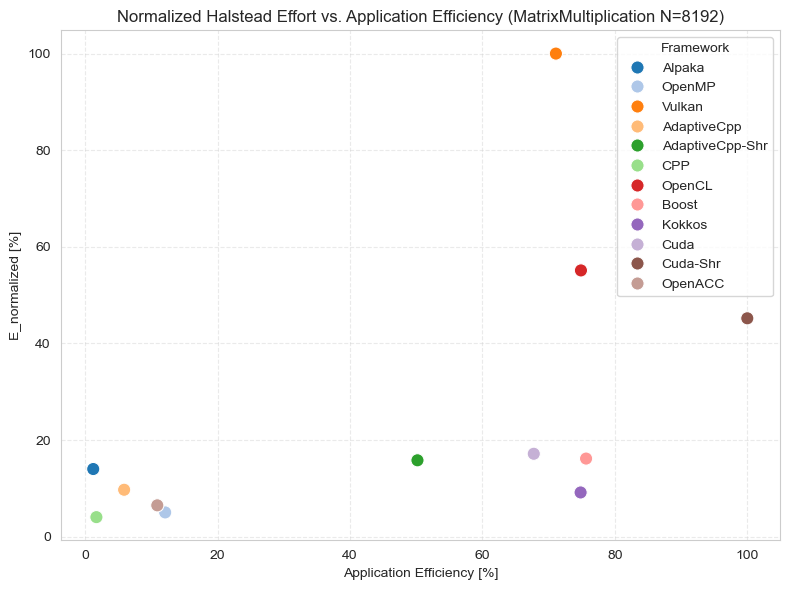

In [62]:
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=df_matMul8192,
    x="Application Efficiency [%]",
    y="E_normalized [%]",
    hue="Framework",
    palette="tab20",
    s=90
)
ax.set_title("Normalized Halstead Effort vs. Application Efficiency (MatrixMultiplication N=8192)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


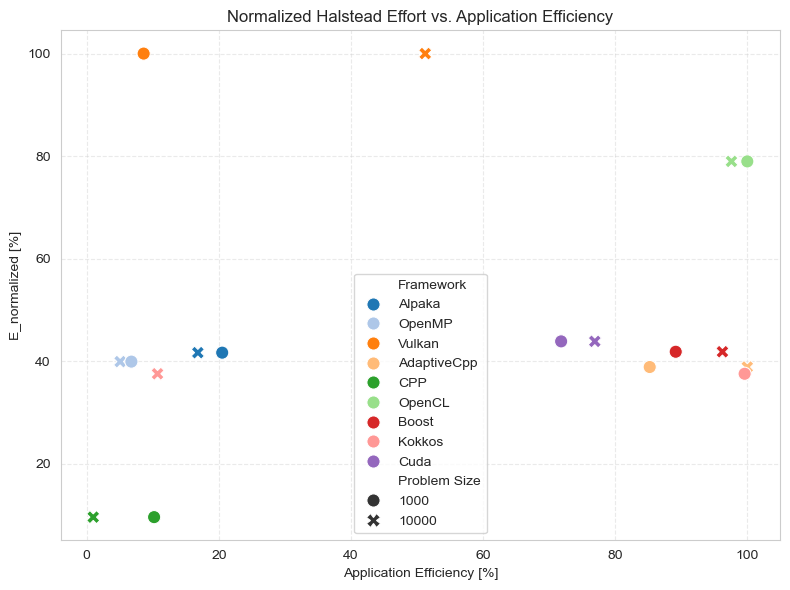

In [77]:
df2 = filter_and_normalize(df_merged, "NBody", 10000, "Wall Clock Time")
df3 = filter_and_normalize(df_merged, "NBody", 1000, "Wall Clock Time")

# Reconstruct Problem Size column and merge
df2 = df2.copy()
df2["Problem Size"] = 10000
df3 = df3.copy()
df3["Problem Size"] = 1000
df_merged_sizes = pd.concat([df2, df3], ignore_index=True)

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=df_merged_sizes,
    x="Application Efficiency [%]",
    y="E_normalized [%]",
    hue="Framework",
    style="Problem Size",
    palette="tab20",
    s=90
)
ax.set_title("Normalized Halstead Effort vs. Application Efficiency")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


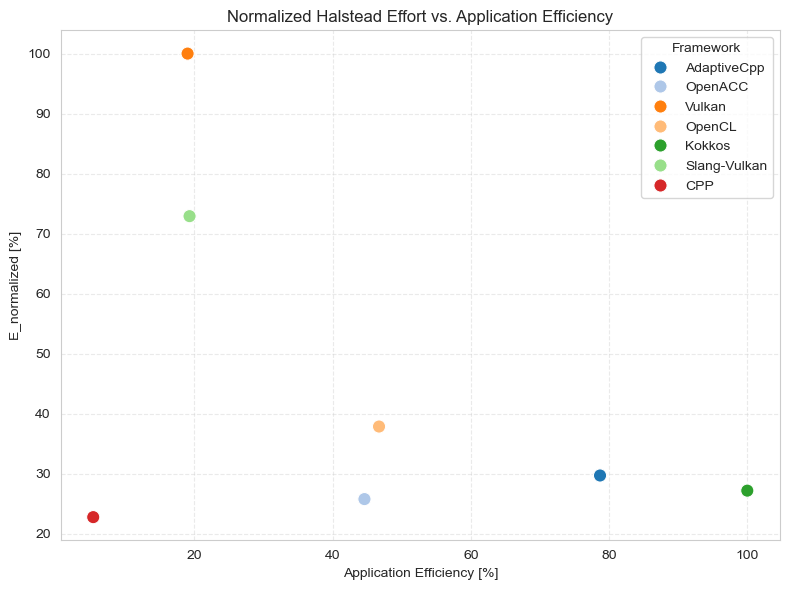

In [83]:
df5 = filter_and_normalize(df_merged, "PolyhedralGravity", 255932, "Wall Clock Time")

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=df5,
    x="Application Efficiency [%]",
    y="E_normalized [%]",
    hue="Framework",
    palette="tab20",
    s=90
)
ax.set_title("Normalized Halstead Effort vs. Application Efficiency")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
